<a href="https://colab.research.google.com/github/ngoanlc25ai/Dissertation/blob/main/GFPGANer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Segmentation Matrix

Matrix đánh giá ảnh sau khi enhance

✅ Patch torchvision OK
📂 Tìm thấy 3 ảnh trong /content/inputs

🔄 Load Real-ESRGAN...
✅ Real-ESRGAN loaded!

🔄 Load GFPGAN...
✅ GFPGAN loaded!

🚀 Bắt đầu xử lý 3 ảnh...

🔄 18_1.jpg (31x32)
   ✅ → 128x128 saved: /content/outputs/18_1_enhanced.png
🔄 18_13.jpg (29x32)
   ✅ → 128x128 saved: /content/outputs/18_13_enhanced.png
🔄 18_4.jpg (28x32)
   ✅ → 128x128 saved: /content/outputs/18_4_enhanced.png

🎉 Hoàn tất! Output tại: /content/outputs


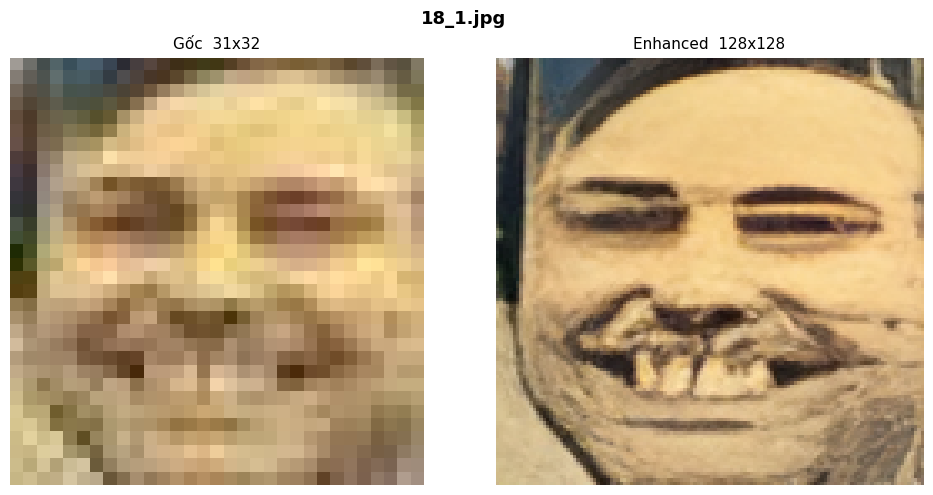

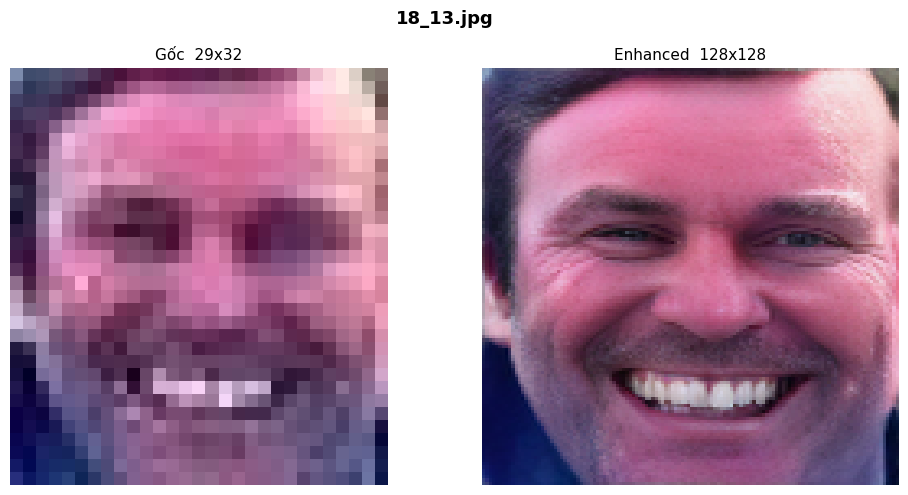

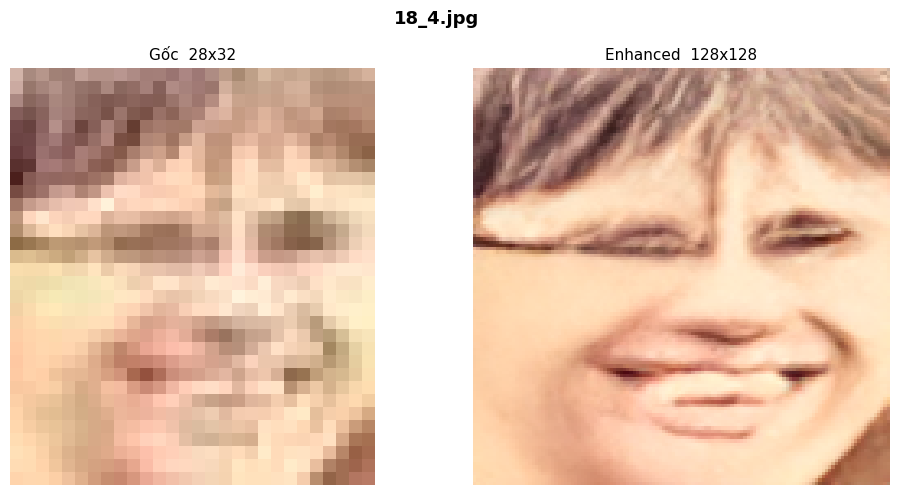

In [5]:
import os, shutil, types, sys
from PIL import Image
import torch

# ════════════════════════════════
# 🔧 FIX torchvision TRƯỚC KHI IMPORT
# ════════════════════════════════
import torchvision.transforms.functional as _F
_fake = types.ModuleType('torchvision.transforms.functional_tensor')
_fake.rgb_to_grayscale = _F.rgb_to_grayscale
sys.modules['torchvision.transforms.functional_tensor'] = _fake
print('✅ Patch torchvision OK')

# ════════════════════════════════
# 📦 Cài dependencies
# ════════════════════════════════
os.system('pip install gfpgan basicsr facexlib realesrgan -q')

# ════════════════════════════════
# ✅ Import SAU KHI patch
# ════════════════════════════════
import cv2
import numpy as np
from realesrgan import RealESRGANer
from gfpgan import GFPGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

# ════════════════════════════════
# ⚙️ CẤU HÌNH — chỉnh tại đây
# ════════════════════════════════

# --- Cách 1: Upload ảnh thủ công lên Colab (thư mục mặc định) ---
# Chạy cell này trước để upload:
#   from google.colab import files
#   uploaded = files.upload()
# Sau đó đặt INPUT_DIR = '/content/' hoặc chỉ folder bạn upload vào

# --- Cách 2: Mount Google Drive ---
# from google.drive import drive
# drive.mount('/content/drive')
# INPUT_DIR = '/content/drive/MyDrive/your_folder'   # ← sửa đường dẫn

# --- Cách 3: Tải dataset từ Kaggle trong Colab ---
# 1. Vào Kaggle → Account → Create API Token → tải kaggle.json
# 2. Chạy:
#    from google.colab import files
#    files.upload()   # upload kaggle.json
#    !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
#    !kaggle datasets download -d chngoanl/tiny-face --unzip -p /content/tiny-face
# Rồi đặt INPUT_DIR = '/content/tiny-face'

INPUT_DIR   = '/content/inputs'      # ← đổi thành đường dẫn ảnh của bạn
OUTPUT_DIR  = '/content/outputs'
TARGET_SIZE = 128

os.makedirs(INPUT_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ════════════════════════════════
# 📋 (Tuỳ chọn) Tải dataset Kaggle tự động
# Bỏ comment block bên dưới nếu muốn dùng dataset chngoanl/tiny-face
# ════════════════════════════════
# import subprocess
# subprocess.run([
#     'kaggle', 'datasets', 'download',
#     '-d', 'chngoanl/tiny-face',
#     '--unzip', '-p', INPUT_DIR
# ], check=True)
# print(f'✅ Dataset đã tải vào {INPUT_DIR}')

# ════════════════════════════════
# 🧹 Xóa ảnh cũ trong output
# ════════════════════════════════
old = [f for f in os.listdir(OUTPUT_DIR) if f.lower().endswith(('.png','.jpg','.jpeg','.webp'))]
if old:
    print(f'🗑️ Xóa {len(old)} ảnh cũ trong {OUTPUT_DIR}...')
    for f in old:
        os.remove(os.path.join(OUTPUT_DIR, f))

# ════════════════════════════════
# 🔍 Kiểm tra ảnh đầu vào
# ════════════════════════════════
img_files = sorted([
    f for f in os.listdir(INPUT_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))
])

if not img_files:
    raise FileNotFoundError(
        f"❌ Không tìm thấy ảnh trong '{INPUT_DIR}'.\n"
        "👉 Hãy upload ảnh vào thư mục đó, hoặc sửa INPUT_DIR "
        "trỏ đúng tới thư mục chứa ảnh của bạn."
    )

print(f'📂 Tìm thấy {len(img_files)} ảnh trong {INPUT_DIR}')

# ════════════════════════════════
# 🔄 Load Models
# ════════════════════════════════
print('\n🔄 Load Real-ESRGAN...')
realesrgan_model = RRDBNet(
    num_in_ch=3, num_out_ch=3,
    num_feat=64, num_block=23, num_grow_ch=32, scale=4
)
upsampler = RealESRGANer(
    scale=4,
    model_path='https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth',
    model=realesrgan_model,
    tile=0, tile_pad=10, pre_pad=0,
    half=torch.cuda.is_available(),
)
print('✅ Real-ESRGAN loaded!')

print('\n🔄 Load GFPGAN...')
gfpganer = GFPGANer(
    model_path='https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.3.pth',
    upscale=4,
    arch='clean',
    channel_multiplier=2,
    bg_upsampler=upsampler,
)
print('✅ GFPGAN loaded!')

# ════════════════════════════════
# 🚀 Xử lý từng ảnh
# ════════════════════════════════
print(f'\n🚀 Bắt đầu xử lý {len(img_files)} ảnh...\n')

for fname in img_files:
    src_path = os.path.join(INPUT_DIR, fname)
    name, _  = os.path.splitext(fname)
    out_path = os.path.join(OUTPUT_DIR, f'{name}_enhanced.png')

    img = cv2.imread(src_path, cv2.IMREAD_COLOR)
    if img is None:
        print(f'⚠️  Không đọc được {fname}, bỏ qua.')
        continue

    h, w = img.shape[:2]
    print(f'🔄 {fname} ({w}x{h})')

    _, _, enhanced = gfpganer.enhance(
        img,
        has_aligned=False,
        only_center_face=False,
        paste_back=True,
        weight=0.5,
    )

    final = cv2.resize(enhanced, (TARGET_SIZE, TARGET_SIZE),
                       interpolation=cv2.INTER_LANCZOS4)
    cv2.imwrite(out_path, final)
    print(f'   ✅ → {TARGET_SIZE}x{TARGET_SIZE} saved: {out_path}')

print(f'\n🎉 Hoàn tất! Output tại: {OUTPUT_DIR}')

# ════════════════════════════════
# 🖼️ Hiển thị kết quả
# ════════════════════════════════
import matplotlib.pyplot as plt

for fname in img_files:
    name, _ = os.path.splitext(fname)
    out_path = os.path.join(OUTPUT_DIR, f'{name}_enhanced.png')

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(fname, fontsize=13, fontweight='bold')

    orig = Image.open(os.path.join(INPUT_DIR, fname))
    axes[0].imshow(orig)
    axes[0].set_title(f'Gốc  {orig.width}x{orig.height}', fontsize=11)
    axes[0].axis('off')

    if os.path.exists(out_path):
        out = Image.open(out_path)
        axes[1].imshow(out)
        axes[1].set_title(f'Enhanced  {out.width}x{out.height}', fontsize=11)
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()